In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import preprocessing, tree
from sklearn.tree import _tree
import matplotlib.pyplot as plt

In [2]:
# training the dt
def train():
    # load sample dataset
    df = pd.read_csv("dt.csv")

    # map year to integer
    year_map = {'First Year': 0, 'Second Year': 1, 'Third Year': 2, 'Fourth Year': 3}
    df['Year'] = df['Year'].map(year_map)

    df = df.drop(columns=["Timestamp"])

    # separate labels (names) from featuresf
    y = df['FirstLast']
    X = df.drop(columns=['FirstLast'])

    # build and save label encoders for categorical columns
    label_encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object':
            le = preprocessing.LabelEncoder()
            X[col] = le.fit_transform(X[col])
            label_encoders[col] = le

    features = X.columns.tolist()

    le_y = preprocessing.LabelEncoder()
    y_encoded = le_y.fit_transform(y)

    # train decision tree of depth exactly 20
    clf = DecisionTreeClassifier(max_depth=20)
    clf.fit(X, y_encoded)

    ## print decision tree structure
    tree.plot_tree(clf, feature_names=features)
    plt.savefig('out.png')
    return clf, features, le_y, label_encoders

In [3]:
# ui to interactively traverse decision tree with yes/no
def tree_walk(clf, feature_names, label_encoder, label_encoders=None):
    tree = clf.tree_
    node = 0
    features = feature_names
    answers = {}

    while tree.children_left[node] != _tree.TREE_LEAF:
        feat_idx = tree.feature[node]
        threshold = tree.threshold[node]
        feat = features[feat_idx]
        
        if label_encoders and feat in label_encoders:
            le = label_encoders[feat]
            mapping = {idx: label for idx, label in enumerate(le.classes_)}
            print(f"Feature '{feat}' label mapping: {mapping}")
        
        print(f"\nIs your {feat} == '{threshold}' or greater? (yes/no): ", end="")
        ans = input().strip().lower()
        if ans in ['yes', 'y']:
            node = tree.children_right[node]
            answers[feat] = f">={threshold}"
        elif ans in ['no', 'n']:
            node = tree.children_left[node]
            answers[feat] = f"<{threshold}"
        else:
            print("Please answer 'yes' or 'no'.")

    value = tree.value[node][0]
    class_idx = value.argmax()
    name = label_encoder.inverse_transform([class_idx])[0]
    print(f"\nBased on your answers: {answers}")
    print(f"Your name is: {name}")

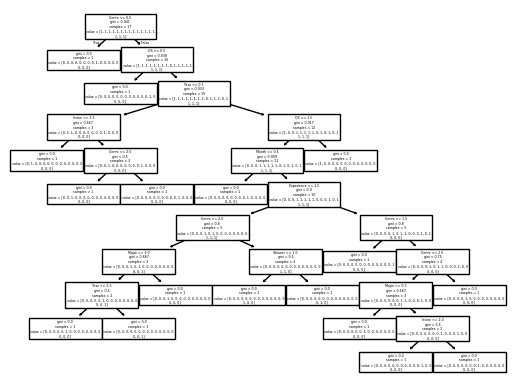

In [4]:
clf, features, le_y, label_encoders = train()


In [5]:
# tree_walk(clf, features, le_y, label_encoders)